# IOR Read/Write – Per-Run Analysis

Combines all per-run CSV files in this directory into a single DataFrame,
extracts `n` (number of nodes) from the filename, counts config occurrences,
and computes the coefficient of variation (CV%) for read/write bandwidth.

In [1]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

## 1. Load and combine all CSVs

Filename convention: `ior_rw_n-{N}_ppn-{PPN}_tx-{TX}_{timestamp}.csv`

The `n`, `ppn`, and `tx` parameters are extracted from the filename and appended as columns.

In [2]:
data_dir = Path(".")  # notebook lives alongside the CSVs
csv_files = sorted(data_dir.glob("ior_rw_n-*.csv"))
print(f"Found {len(csv_files)} CSV files")

frames = []
for f in csv_files:
    m = re.search(r'_n-(\d+)_ppn-(\d+)_tx-(\w+)_', f.stem)
    if not m:
        print(f"  skipping (no match): {f.name}")
        continue
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df["n"]        = int(m.group(1))
    df["ppn"]      = int(m.group(2))
    df["tx"]       = m.group(3).upper()   # normalise: 2M, 16M
    df["filename"] = f.name
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
combined["access"]   = combined["access"].str.strip().str.lower()
combined["bw_GiB_s"] = combined["bw(MiB/s)"] / 1024.0

print(f"Total rows : {len(combined)}")
combined.head()

Found 58 CSV files
Total rows : 1120


,access,bw(MiB/s),IOPS,Latency,block(KiB),xfer(KiB),open(s),wr/rd(s),close(s),total(s),numTasks,iter,n,ppn,tx,filename,bw_GiB_s
0,write,1.630644e+06,103035.6568,0.0385,131072.0,16384.0,0.0067,0.3180,0.0212,0.3215,256,0,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782531633.csv,1592.426036
1,read,1.543536e+06,97398.5885,0.0408,131072.0,16384.0,0.0064,0.3364,0.0159,0.3397,256,0,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782531633.csv,1507.359373
2,write,1.623318e+06,102531.4154,0.0382,131072.0,16384.0,0.0074,0.3196,0.0263,0.3230,256,1,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782531633.csv,1585.271770
3,read,1.625105e+06,102616.7726,0.0388,131072.0,16384.0,0.0066,0.3193,0.0192,0.3226,256,1,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782531633.csv,1587.016186
4,write,1.631780e+06,103095.2464,0.0380,131072.0,16384.0,0.0068,0.3178,0.0261,0.3213,256,2,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782531633.csv,1593.535612


In [3]:
out_path = data_dir / "ior_rw_combined.csv"
combined.to_csv(out_path, index=False)
print(f"Saved combined CSV → {out_path.resolve()}")

Saved combined CSV → /Users/xmei/Documents/LDRD/pdsw26_daos-bench-res/results/aurora/ior/ior-rw/ior_rw_combined.csv


## 2. Config counts

Each row in a CSV = one iter. Count how many iters exist per `(n, ppn, tx, access)` config.

In [4]:
config_cols = ["n", "ppn", "tx"]

iter_counts = (
    combined.groupby(config_cols + ["access"])
    .size()
    .rename("num_iters")
    .reset_index()
    .sort_values(config_cols + ["access"])
    .reset_index(drop=True)
)
display(iter_counts)

,n,ppn,tx,access,num_iters
0,1,8,16M,read,20
1,1,8,16M,write,20
2,1,8,2M,read,20
3,1,8,2M,write,20
4,1,16,16M,read,20
...,...,...,...,...,...
91,32,32,2M,write,10
92,32,48,16M,read,10
93,32,48,16M,write,10
94,32,48,2M,read,10


## 3. CV% for Read / Write bandwidth

CV (coefficient of variation) = σ / μ × 100 %, computed **across all iters** (rows) per config.  
Each row in the CSV is one iter measurement.

In [5]:
def cv_pct(x):
    return x.std(ddof=1) / x.mean() * 100 if len(x) > 1 and x.mean() != 0 else np.nan

stats = (
    combined.groupby(config_cols + ["access"])["bw_GiB_s"]
    .agg(mean_GiB_s="mean", std_GiB_s="std", cv_pct=cv_pct, num_iters="count")
    .reset_index()
    .sort_values(config_cols + ["access"])
)

CV_THRESH = 5.0

def highlight_high_cv(row):
    color = "background-color: #ffe0e0" if pd.notna(row["cv_pct"]) and row["cv_pct"] > CV_THRESH else ""
    return [color] * len(row)

display(
    stats.style
    .apply(highlight_high_cv, axis=1)
    .format({"mean_GiB_s": "{:.3f}", "std_GiB_s": "{:.3f}", "cv_pct": "{:.2f}"}, na_rep="—")
    .set_caption(f"CV% across iters per config × access  (red = CV > {CV_THRESH}%)")
)

,n,ppn,tx,access,mean_GiB_s,std_GiB_s,cv_pct,num_iters
0,1,8,16M,read,64.352,0.260,0.40,20
1,1,8,16M,write,87.436,0.869,0.99,20
2,1,8,2M,read,12.304,1.779,14.46,20
3,1,8,2M,write,22.080,1.831,8.29,20
4,1,16,16M,read,101.595,0.149,0.15,20
5,1,16,16M,write,126.272,0.751,0.59,20
6,1,16,2M,read,23.000,0.060,0.26,20
7,1,16,2M,write,47.523,0.514,1.08,20
8,1,32,16M,read,137.408,0.923,0.67,20
9,1,32,16M,write,158.287,0.554,0.35,20


### CV% bar chart

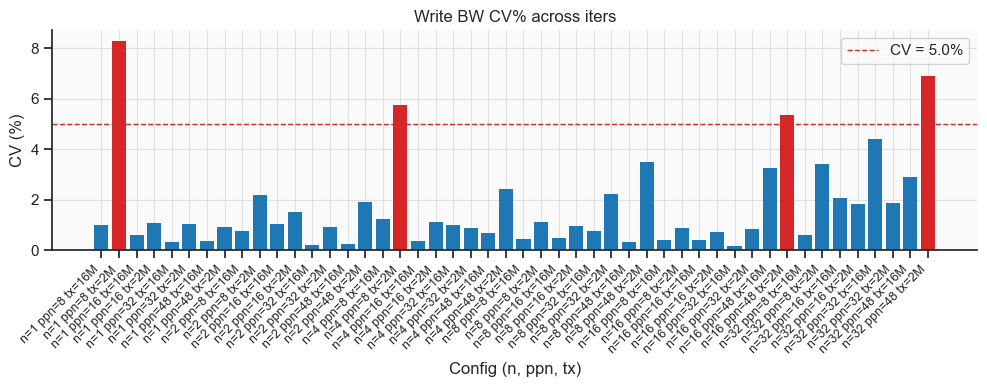

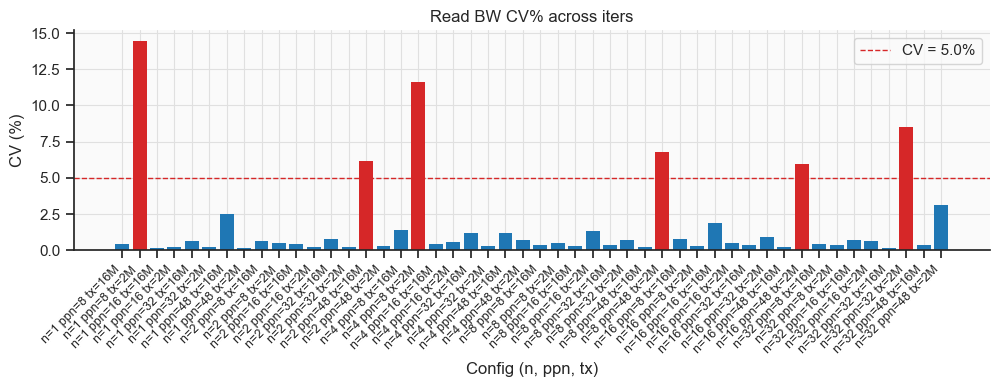

In [6]:
sns.set_theme(style="ticks")
mpl.rcParams.update({
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e0e0e0",
    "grid.linewidth":    0.8,
    "axes.facecolor":    "#fafafa",
    "figure.facecolor":  "white",
    "font.size":         11,
})

for access_type in ["write", "read"]:
    sub = stats[stats["access"] == access_type].copy()
    sub["config"] = sub.apply(
        lambda r: f"n={int(r.n)} ppn={int(r.ppn)} tx={r.tx}", axis=1
    )
    sub = sub.sort_values(["n", "ppn", "tx"])

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["#d62728" if v > CV_THRESH else "#1f77b4" for v in sub["cv_pct"]]
    ax.bar(sub["config"], sub["cv_pct"], color=colors, edgecolor="none")
    ax.axhline(CV_THRESH, color="#d62728", linewidth=1, linestyle="--", label=f"CV = {CV_THRESH}%")
    ax.set_xlabel("Config (n, ppn, tx)")
    ax.set_ylabel("CV (%)")
    ax.set_title(f"{access_type.capitalize()} BW CV% across iters")
    ax.legend()
    plt.xticks(rotation=45, ha="right", fontsize=9)
    fig.tight_layout()
    plt.show()

## 4. Peak Read/Write BW

In [7]:
peak_rows = []
for n_val in [1, 2, 4, 8, 16, 32]:
    for access_type in ["write", "read"]:
        sub = combined[(combined["n"] == n_val) & (combined["access"] == access_type)]
        idx = sub["bw_GiB_s"].idxmax()
        row = sub.loc[idx]
        peak_rows.append({
            "n":          n_val,
            "access":     access_type,
            "peak_BW_GiB_s": row["bw_GiB_s"],
            "ppn":        int(row["ppn"]),
            "tx":         row["tx"],
            "iter":       int(row["iter"]),
            "filename":   row["filename"],
        })

peak_df = pd.DataFrame(peak_rows)
display(
    peak_df.style
    .format({"peak_BW_GiB_s": "{:.3f}"})
    .set_caption("Peak BW per n × access (best single iter across all configs)")
    .hide(axis="index")
)

n,access,peak_BW_GiB_s,ppn,tx,iter,filename
1,write,170.552,48,16M,9,ior_rw_n-1_ppn-48_tx-16m_1782525887.csv
1,read,139.247,32,16M,4,ior_rw_n-1_ppn-32_tx-16m_1782526180.csv
2,write,329.699,48,16M,0,ior_rw_n-2_ppn-48_tx-16M_1782542088.csv
2,read,274.622,32,16M,7,ior_rw_n-2_ppn-32_tx-16M_1782541990.csv
4,write,618.604,48,16M,5,ior_rw_n-4_ppn-48_tx-16M_1782540627.csv
4,read,575.600,48,16M,6,ior_rw_n-4_ppn-48_tx-16M_1782540627.csv
8,write,1124.799,48,16M,9,ior_rw_n-8_ppn-48_tx-16M_1782538751.csv
8,read,978.811,48,16M,2,ior_rw_n-8_ppn-48_tx-16M_1782538751.csv
16,write,1983.189,48,16M,8,ior_rw_n-16_ppn-48_tx-16M_1782531799.csv
16,read,1838.100,48,16M,5,ior_rw_n-16_ppn-48_tx-16M_1782531799.csv


## 5. Scaling charts: peak BW vs nodes / PPN

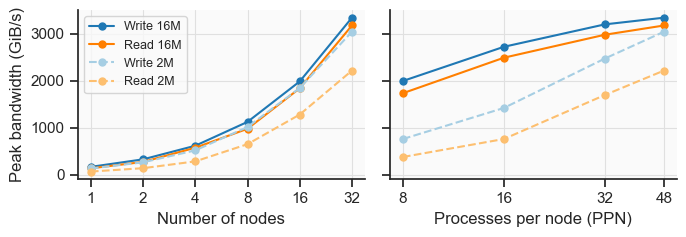

In [8]:
# Peak BW = max single-iter BW across all runs at each (n or ppn, tx, access) combo
peak = (
    combined.groupby(["n", "ppn", "tx", "access"])["bw_GiB_s"]
    .max()
    .reset_index()
    .rename(columns={"bw_GiB_s": "peak_GiB_s"})
)

# Styling helpers — Paired palette: light/dark pairs per hue
paired = mpl.colormaps["Paired"].colors
LINE_PROPS = {
    ("write", "16M"): {"color": paired[1], "linestyle": "-",  "alpha": 1.0},
    ("write", "2M"):  {"color": paired[0], "linestyle": "--", "alpha": 1.0},
    ("read",  "16M"): {"color": paired[7], "linestyle": "-",  "alpha": 1.0},
    ("read",  "2M"):  {"color": paired[6], "linestyle": "--", "alpha": 1.0},
}

MARKER = "o"
MS = 5

int_fmt = mpl.ticker.FuncFormatter(lambda x, _: f"{int(x)}")

def add_lines(ax, df, x_col):
    for tx in ["16M", "2M"]:
        for access in ["write", "read"]:
            sub = (
                df[(df["tx"] == tx) & (df["access"] == access)]
                .groupby(x_col)["peak_GiB_s"].max()
                .reset_index()
                .sort_values(x_col)
            )
            if sub.empty:
                continue
            props = LINE_PROPS[(access, tx)]
            ax.plot(
                sub[x_col], sub["peak_GiB_s"],
                color=props["color"],
                linestyle=props["linestyle"],
                alpha=props["alpha"],
                marker=MARKER,
                markersize=MS,
                label=f"{access.capitalize()} {tx}",
            )

fig, (ax_n, ax_ppn) = plt.subplots(1, 2, figsize=(7, 2.5), sharey=True)

# ── (a) Peak BW vs number of nodes ─────────────────────────────────────────
add_lines(ax_n, peak, "n")
ax_n.set_xlabel("Number of nodes")
ax_n.set_ylabel("Peak bandwidth (GiB/s)")
ax_n.set_xscale("log", base=2)
ax_n.xaxis.set_major_formatter(int_fmt)
ax_n.legend(frameon=True, fontsize=9)

# ── (b) Peak BW vs PPN ─────────────────────────────────────────────────────
add_lines(ax_ppn, peak, "ppn")
ax_ppn.set_xlabel("Processes per node (PPN)")
ax_ppn.set_xscale("log", base=2)
ppn_ticks = sorted(peak["ppn"].unique().tolist())
ax_ppn.set_xticks(ppn_ticks)
ax_ppn.xaxis.set_major_formatter(int_fmt)
ax_ppn.xaxis.set_minor_locator(mpl.ticker.NullLocator())

fig.tight_layout()
plt.show()

## 6. Raw BW scatter: all iters vs number of nodes

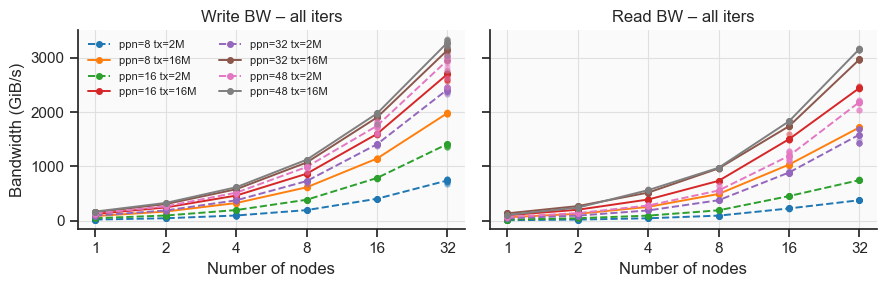

In [9]:
ppn_vals = sorted(combined["ppn"].unique())   # [8, 16, 32, 48]
tx_vals  = ["2M", "16M"]

cmap = mpl.colormaps["tab10"].colors
combo_colors = {}
for i, ppn_v in enumerate(ppn_vals):
    for j, tx_v in enumerate(tx_vals):
        combo_colors[(ppn_v, tx_v)] = cmap[i * len(tx_vals) + j]

linestyles = {"2M": "--", "16M": "-"}

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)

for ax, access_type in zip(axes, ["write", "read"]):
    for ppn_v in ppn_vals:
        for tx_v in tx_vals:
            sub = combined[
                (combined["access"] == access_type) &
                (combined["ppn"] == ppn_v) &
                (combined["tx"] == tx_v)
            ]
            if sub.empty:
                continue
            color = combo_colors[(ppn_v, tx_v)]
            ax.scatter(
                sub["n"], sub["bw_GiB_s"],
                color=color, s=20, alpha=0.5, linewidths=0, zorder=3,
            )
            med = sub.groupby("n")["bw_GiB_s"].median().reset_index()
            ax.plot(
                med["n"], med["bw_GiB_s"],
                color=color, linestyle=linestyles[tx_v],
                linewidth=1.4, marker="o", markersize=4,
                label=f"ppn={ppn_v} tx={tx_v}",
            )
    ax.set_xlabel("Number of nodes")
    ax.set_title(f"{access_type.capitalize()} BW – all iters")
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(int_fmt)

axes[0].set_ylabel("Bandwidth (GiB/s)")
axes[0].legend(frameon=False, fontsize=8, ncol=2)

fig.tight_layout()
plt.show()


## 7. PPN × N (total clients) analysis

Group all runs by total client count (`n × ppn`) and transfer size, collapsing the individual `n`/`ppn` split. This shows whether BW depends on the *total number of processes* regardless of how they are distributed across nodes.

,num_clients,tx,access,num_runs,mean_GiB_s,median_GiB_s,std_GiB_s,cv_pct
0,8,16M,read,20,64.352,64.322,0.260,0.40
1,16,16M,read,30,110.711,101.675,13.122,11.85
2,32,16M,read,40,183.302,170.496,50.160,27.36
3,48,16M,read,20,108.668,108.147,2.728,2.51
4,64,16M,read,30,384.915,391.332,92.126,23.93
5,96,16M,read,10,242.153,242.453,14.866,6.14
6,128,16M,read,30,761.858,734.607,213.311,28.00
7,192,16M,read,10,565.629,564.308,6.781,1.20
8,256,16M,read,30,1396.432,1500.641,323.614,23.17
9,384,16M,read,10,975.102,975.339,2.443,0.25


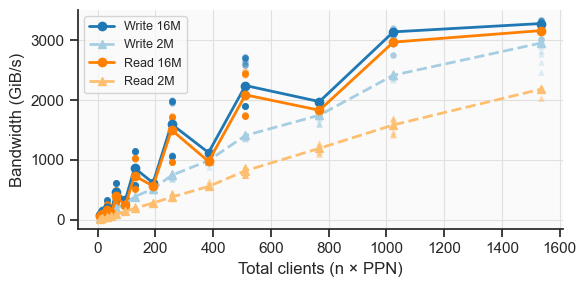

In [10]:
combined["num_clients"] = combined["n"] * combined["ppn"]

# ── Stats table ─────────────────────────────────────────────────────────────
client_stats = (
    combined.groupby(["num_clients", "tx", "access"])["bw_GiB_s"]
    .agg(
        num_runs="count",
        mean_GiB_s="mean",
        median_GiB_s="median",
        std_GiB_s="std",
        cv_pct=cv_pct,
    )
    .reset_index()
    .sort_values(["access", "tx", "num_clients"])
    .reset_index(drop=True)
)

display(
    client_stats.style
    .format({
        "mean_GiB_s":   "{:.3f}",
        "median_GiB_s": "{:.3f}",
        "std_GiB_s":    "{:.3f}",
        "cv_pct":       "{:.2f}",
    })
    .set_caption("BW stats grouped by total clients (n × ppn) × tx × access")
)

# ── Single figure: raw scatter + median line ─────────────────────────────────
SERIES = [
    ("write", "16M", paired[1],  "-",  "o",  "Write 16M"),
    ("write",  "2M", paired[0], "--",  "^",  "Write 2M"),
    ("read",  "16M", paired[7],  "-",  "o",  "Read 16M"),
    ("read",   "2M", paired[6], "--",  "^",  "Read 2M"),
]

fig, ax = plt.subplots(figsize=(6, 3))

for access_type, tx_v, color, ls, marker, label in SERIES:
    sub = combined[
        (combined["access"] == access_type) &
        (combined["tx"] == tx_v)
    ]
    if sub.empty:
        continue

    # Raw scatter
    ax.scatter(
        sub["num_clients"], sub["bw_GiB_s"],
        color=color, marker=marker, s=22, alpha=0.35, linewidths=0, zorder=3,
    )

    # Median line
    med = sub.groupby("num_clients")["bw_GiB_s"].median().reset_index()
    ax.plot(
        med["num_clients"], med["bw_GiB_s"],
        color=color, linestyle=ls, linewidth=2,
        marker=marker, markersize=6,
        label=label, zorder=4,
    )

ax.set_xlabel("Total clients (n × PPN)")
ax.set_ylabel("Bandwidth (GiB/s)")
# ax.set_title("BW vs total clients – raw scatter + median")
ax.legend(frameon=True, fontsize=9)
fig.tight_layout()
plt.show()
